# Step 1: Load Dataset

In [ ]:
import pandas as pd
import os

# Define the base path for the dataset, as suggested by the error message
base_dataset_path = "/kaggle/input/car-price-predictionused-cars"

# List files in the dataset directory to verify the filename
print(f"Files in dataset directory: {os.listdir(base_dataset_path)}")

# Construct the full path to the desired file
file_name = "car data.csv" # Correcting the filename based on the directory listing
full_file_path = os.path.join(base_dataset_path, file_name)

# Load the dataset into a pandas DataFrame
df = pd.read_csv(full_file_path)

print(df.head())

Files in dataset directory: ['car data.csv']
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


# Step 2: Explore Dataset

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Shape: (301, 9)

Columns:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Data Types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object


# Step 3: Data Cleaning

In [ ]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove missing values
df.dropna(inplace=True)

print(df.shape)

(299, 9)


# Step 4: Visualize Data
## Distribution of Car Prices

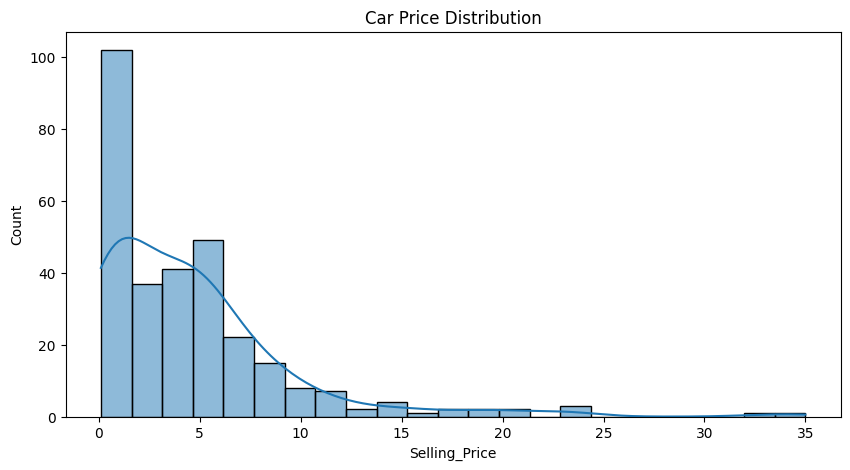

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(df['Selling_Price'], kde=True)

plt.title("Car Price Distribution")
plt.show()

# Correlation Heatmap


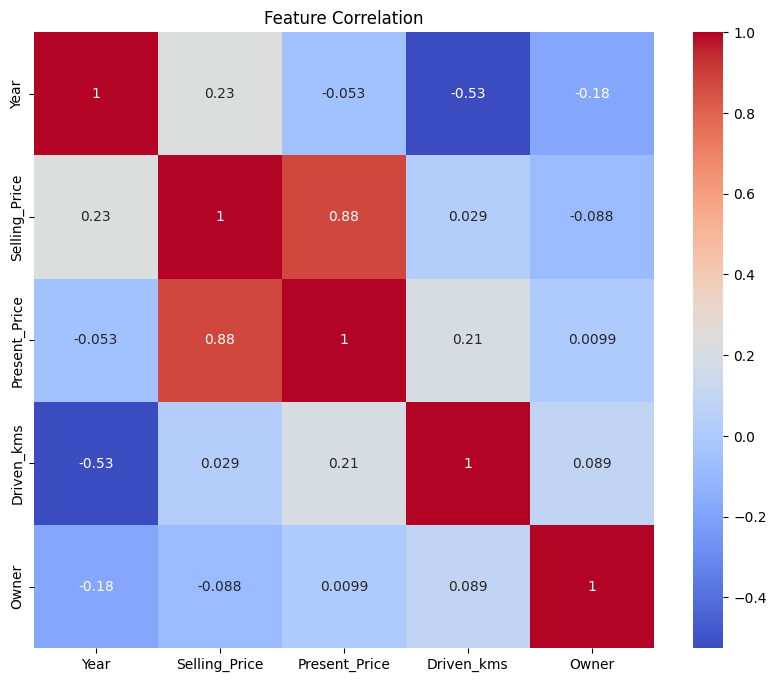

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation")
plt.show()

# Step 5: Encode Categorical Features


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Step 6: Feature Selection

Assuming the target column is price:


In [ ]:
X = df.drop('Selling_Price', axis=1)

y = df['Selling_Price']

# Step 7: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Step 8: Train Regression Model
## Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# Step 9: Make Predictions

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ 9.6224  8.052   0.4403  7.2005 17.4475  5.2965  6.8316  1.1585  8.5385
  0.2879]


# Step 10: Evaluate Model
Mean Absolute Error (MAE) &
Root Mean Squared Error (RMSE)


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 1.3950900000000004
RMSE: 3.5033992578161386
R2 Score: 0.5237775391473747


# Step 11: Predict New Car Price

In [ ]:
import pandas as pd

# The model expects 8 features in the following order:
# 'Car_Name', 'Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'
# Let's create a sample with representative values for each:
# For 'Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner' we use encoded values.
# These values (e.g., 50 for Car_Name, 1 for Fuel_Type (Diesel), 0 for Selling_type (Dealer), 1 for Transmission (Manual), 0 for Owner)
# are examples based on the dataset's transformations.
sample_data = [[
    50,     # Car_Name (example encoded value)
    2019,   # Year
    10.0,   # Present_Price (Adjusted from 'engine cc' to be a realistic price in Lakhs)
    50000,  # Driven_kms
    1,      # Fuel_Type (example encoded: 1 could be Diesel)
    0,      # Selling_type (example encoded: 0 could be Dealer)
    1,      # Transmission (example encoded: 1 could be Manual)
    0       # Owner
]]

# Create a DataFrame for the sample with correct column names
# This is important to ensure the feature order is correct and to prevent warnings
sample_df = pd.DataFrame(sample_data, columns=X.columns)

predicted_price = model.predict(sample_df)

print("Predicted Price:", predicted_price[0])

Predicted Price: 7.704500000000004
